Price Prediction Model:

In this notebook I build a regression model to predict car prices.

Based on earlier EDA, curb weight showed a strong relationship with price. This variable was used as the primary predictor in this regression model.

The modeling process includes:

-loading the cleaned dataset
-splitting the data into train/test split
-fitting the regression model
-visualizing predicted vs actual prices



Load clean data:

Rows with missing data are removed so the regression model can be trained properly.

In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/clean/automobile_clean.csv")

df.head()
df.dropna(subset=["price"]).copy()


#the cleaned dataset created in clean.ipynb is loaded for modeling

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


In [17]:

df = df.dropna(subset=["price"]).copy()
df["price"].isna().sum()



np.int64(0)

Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

x = df[["curb_weight"]]
y = df[["price"]]

x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)

#The dataset is divided into training and testing sets. The training set trains the regression model, while the testing set evaluates how well the model performs with unseen data.


Baseline Linear Regression:

A regression model is used to predict car prices based on curb weight. It models this relationship between the predictor variable (curb weight) and the target variable (price), by fitting a straight line that minimizes prediction error.


In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Evaluation:

The model is evaluted with two metrics:

-R2 score: how much variation in price is explained by the model. The score was 0.699, so we can say  curb weight explains 70% of the variation in car price.

-Mean Squared Error (MSE): measures the average squared difference between predicted and actual prices.

-RMSE is roughly $4,900 meaning this models predictions are within $5,000 of the actual price.


In [22]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R2: 0.6991601602612142
MSE: 24332254.56082221
RMSE: 4932.773516068036


Predicted vs Actual Prices:

The plot below compares the predicted prices to the actual prices in the testing dataset.

The regression line is the predicted relationship between curb weight and car price.

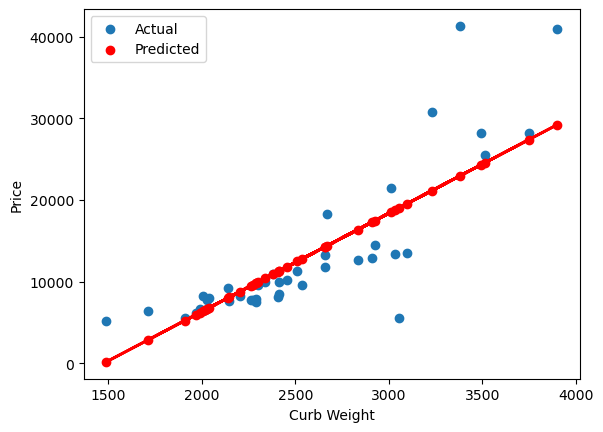

In [6]:
import matplotlib.pyplot as plt

plt.scatter(x_test, y_test, label="Actual")
plt.scatter(x_test, y_pred, color = "red" , label = "Predicted")
plt.plot(x_test, y_pred, color = "red", linewidth = 2)
plt.xlabel("Curb Weight")
plt.ylabel("Price")
plt.legend()
plt.show()

Interpretation:

The regression model shows a positive relationship between curb weight and automobile price. The upward slope of the regression line indicates heavier 
vehicles have higher prices. The R2 score was 0.70, curb weight explains 70% of the variation in vehicle price in this dataset. Even though the relation ship is strong, the points scattered around the regression line suggest other factors are responsible for car price.

If I had more time for this project I'd look into what other factors influence car price beyond weight. Horsepower? Engine Size? Manufacturer? What about different types of cars like sports cars? For example, sports cars are often engineered to be lightweight while still being highly priced due to powerful engines and specialized design.
